<details>
  <summary><strong>MIT License (click to expand)</strong></summary>

  <pre>
MIT License
Copyright (c) 2023-2026 AI Course Notebook Contributors
Repository: https://github.com/arch-inform-kaken-group/ai-course-notebooks

Permission is hereby granted, free of charge, to any person obtaining a copy
of this software and associated documentation files (the "Software"), to deal
in the Software without restriction, including without limitation the rights
to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
copies of the Software, and to permit persons to whom the Software is
furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all
copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE
AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM,
OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE
SOFTWARE.
  </pre>
</details>


# Text Classification of Amazon Reviews Using a Neural Network

The goal of this hands-on session is to give you a basic, hands-on experience of processing language (text data) with a neural network.


## Downloading the Data
Here we use the "Amazon Multilingual Counterfactual Dataset (AMCD)," a set of Amazon product-review data published on GitHub (URL: https://github.com/amazon-research/amazon-multilingual-counterfactual-dataset).

<br>

[References]<br>
[I Wish I Would Have Loved This One, But I Didn't – A Multilingual Dataset for Counterfactual Detection in Product Review](https://aclanthology.org/2021.emnlp-main.568) (O'Neill et al., EMNLP 2021)<br>
arXiv:<br>
https://arxiv.org/abs/2104.06893

## What is a Counterfactual Dataset?

Product-search systems used on e-commerce sites such as Amazon also make use of user reviews in order to improve search accuracy. However, some reviews end up acting as "*noise*" for the search system.
<br>
<br>
*I would have been content with purchasing this iPhone, if it came with a warranty!*
<br>
<br>
Although this review actually points out that the product does **not** come with a warranty, if it is fed into a product-search system it would still be returned as a hit for queries such as "iPhone" or "with a warranty."

A statement that contains such words describing something contrary to fact is called a *counterfactual statement*, and a dataset that collects such statements is called a *Counterfactual Dataset*.

In [ ]:
# Retrieve the dataset from GitHub
!git clone https://github.com/amazon-research/amazon-multilingual-counterfactual-dataset.git

fatal: destination path 'amazon-multilingual-counterfactual-dataset' already exists and is not an empty directory.


### Checking GPU availability and the TensorFlow version

In [ ]:
!nvidia-smi

Tue May 26 04:34:54 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   58C    P8             14W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import tensorflow as tf
import sklearn
import os

print('TensorFlow version:',tf.__version__)
print('scikit-learn version:',sklearn.__version__)

restart_flag = False

if tf.__version__ != '2.20.0':
    !pip install -q --upgrade tensorflow==2.20.0
    print('TensorFlow version:',tf.__version__)
    restart_flag = True

if sklearn.__version__ != '1.6.1':
    !pip install -q --upgrade scikit-learn==1.6.1
    print('scikit-learn version:',sklearn.__version__)
    restart_flag = True

# The following runs only if the library versions were changed.
if restart_flag :
    print("The runtime will be restarted automatically because the library versions were changed.")
    print("On Colab, a warning saying [the session crashed for an unknown reason] will appear at the bottom left,")
    print("but you can safely ignore it and simply run the following code cells.")
    # We intentionally crash the runtime in order to restart it.
    get_ipython().kernel.do_shutdown(restart=True)



TensorFlow version: 2.20.0
scikit-learn version: 1.6.1


### Importing libraries

In [ ]:
import os # os: standard library; handles OS-dependent operations (environment variables, creating folders, etc.)
import datetime # datetime: standard library; handles date/time-related data
import random # random: standard library; pseudo-random number generator
import numpy as np # numpy: a library for numerical computing
import pandas as pd # pandas: a library for tabular data
from IPython.display import display # display: prints some data more nicely than print() in environments such as Colab
import matplotlib.pylab as plt # matplotlib: a library for plotting graphs
import seaborn as sns # seaborn: a library for plotting graphs
import tensorflow as tf # TensorFlow: a deep learning library

import glob # glob: standard library; retrieves file paths

### Fixing the random seed of the pseudo-random number generator

* We fix the sequence of pseudo-random numbers generated and used in the program below.
* A random seed is the value used to initialize the generator when producing a pseudo-random sequence.
* If it is not specified explicitly, it is initialized from the current time, etc.
* Here we fix the random seed in order to ensure reproducibility (so that the same pseudo-random sequence is generated no matter who runs it or when).

<small> * Note: On Colab, exact reproducibility may still be difficult due to differences in the assigned CPU/GPU and library versions.</small>

In [ ]:
def set_seed(seed=123):
    # Fix the hash seed
    os.environ["PYTHONHASHSEED"] = str(seed)
    # Third-party library: make TensorFlow's neural network operations deterministic
    os.environ['TF_DETERMINISTIC_OPS'] = 'true'
    # Third-party library: make TensorFlow's neural network operations deterministic
    os.environ['TF_CUDNN_DETERMINISTIC'] = 'true'
    # Python standard library: fix the seed of random
    random.seed(seed)
    # Third-party library: fix the seed of NumPy
    np.random.seed(seed)
    # Third-party library: fix the seed of TensorFlow
    tf.random.set_seed(seed)

set_seed(42)

### Loading the dataset

We now load the dataset that we downloaded.
It has been extracted into the following directory.

/content/amazon-multilingual-counterfactual-dataset/data/EN_train.tsv<br>
/content/amazon-multilingual-counterfactual-dataset/data/EN_valid.tsv<br>
/content/amazon-multilingual-counterfactual-dataset/data/EN_test.tsv<br>

File name | Purpose | Description
--- | --- | ---
train | Training data | Data used to train the model
valid | Validation data | Data used to validate the model's accuracy during training. It is recorded at each iteration of training and used to evaluate whether performance on unseen data is improving (i.e., whether the model is generalizing).
test | Test data | Data used to test how accurate the finished model is

Each row of this dataset contains the following:

Column | Description | Example
--- | --- | ---
0 | sentence | The length was fine, but the width seemed a little tight.
1 | is_counterfactual | 1 (TRUE / counterfactual), 0 (FALSE / factual)

The dataset files are tab-separated (TSV) files.



In [ ]:
# Read the files with pandas' read_csv function, specifying tab as the separator.
df_train = pd.read_csv("./amazon-multilingual-counterfactual-dataset/data/EN_train.tsv", sep='\t')
df_valid = pd.read_csv("./amazon-multilingual-counterfactual-dataset/data/EN_valid.tsv", sep='\t')
df_test = pd.read_csv("./amazon-multilingual-counterfactual-dataset/data/EN_test.tsv", sep='\t')

# Display the first 5 rows to check that the files were loaded correctly.
display(df_valid.head())

,sentence,is_counterfactual
0,Quintus prophesied that they would be martyrs ...,0
1,Would be great to have on my tablet instead of...,0
2,I just wish it would come with a plastic pole ...,1
3,It only utilizes one side and the insert doesn...,0
4,I also wished the colorful print material in t...,1


Let's check the number of records we loaded.

In [ ]:
print('Number of records loaded (train): {}'.format(len(df_train)))
print('Number of records loaded (valid): {}'.format(len(df_valid)))
print('Number of records loaded (test): {}'.format(len(df_test)))

Number of records loaded (train): 4018
Number of records loaded (valid): 335
Number of records loaded (test): 670


### Replacing numbers

Here we replace numbers that appear in the text with a single symbol (for example, 0).
The reason for replacing numbers is that numeric expressions are highly varied and occur frequently, yet they are often of little use for natural language processing tasks.

In [ ]:
# Define a function that replaces all numbers, assumed to be largely irrelevant, with 0
import re
def replace_number_to_zero(text):
    changed_text = re.sub(r'[0-9]+', "0", text) # half-width digits
    changed_text = re.sub(r'[０-９]+', "0", changed_text) # full-width digits
    return changed_text

In [ ]:
# Before conversion
display(df_train[52:58])

,sentence,is_counterfactual
52,Was going to charge the batteries when the lig...,0
53,The sound is nice and true and the signal does...,0
54,Packaged well and comes with a carrying case t...,0
55,"""Saved money but it was a 45 minute clean and ...",0
56,I wish I would have LOVED this one but I didn't.,1
57,"They are loose at the knee, but it doesn't mat...",0


In [ ]:
df_train['sentence'] = df_train['sentence'].map(replace_number_to_zero)
df_test['sentence'] = df_test['sentence'].map(replace_number_to_zero)
df_valid['sentence'] = df_valid['sentence'].map(replace_number_to_zero)

# After conversion
display(df_train[52:58])

,sentence,is_counterfactual
52,Was going to charge the batteries when the lig...,0
53,The sound is nice and true and the signal does...,0
54,Packaged well and comes with a carrying case t...,0
55,"""Saved money but it was a 0 minute clean and r...",0
56,I wish I would have LOVED this one but I didn't.,1
57,"They are loose at the knee, but it doesn't mat...",0


### Removing stop words

A stop word is a word that is excluded from processing during natural language processing because it is generally considered unhelpful, among other reasons. In English, typical examples are function words such as articles, prepositions, conjunctions, and pronouns (e.g., "the," "a," "is," "and," "of").

Here, we define such words in advance and remove any word contained in this list from the text.

In this notebook we use the English stop-word list provided by NLTK (the Natural Language Toolkit), one of the most widely used stop-word lists for English.



In [ ]:
from nltk.corpus import stopwords
import nltk

nltk.download('stopwords')
stop_words = stopwords.words('english')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Let's check which words are defined as stop words.

In [ ]:
print(stop_words)

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [ ]:
def remove_stopwords(sentence):
  sentence = [w for w in sentence.split() if w not in set(stop_words)]
  return ' '.join(sentence)

display(df_valid.head())

df_train['sentence'] = df_train['sentence'].map(remove_stopwords)
df_test['sentence'] = df_test['sentence'].map(remove_stopwords)
df_valid['sentence'] = df_valid['sentence'].map(remove_stopwords)


display(df_valid.head())

,sentence,is_counterfactual
0,Quintus prophesied that they would be martyrs ...,0
1,Would be great to have on my tablet instead of...,0
2,I just wish it would come with a plastic pole ...,1
3,It only utilizes one side and the insert doesn...,0
4,I also wished the colorful print material in t...,1


,sentence,is_counterfactual
0,Quintus prophesied would martyrs one day day.,0
1,Would great tablet instead carrying book.,0
2,I wish would come plastic pole instead metal I...,1
3,It utilizes one side insert window ID.,0
4,I also wished colorful print material front wo...,1


### Parameter settings

In [ ]:
NUM_LABELS = 2     # Number of classification labels (Negative:Positive = 0:1)
VOCAB_SIZE = 30000  # Maximum number of words to analyze (vocabulary size)
MAX_LENGTH = 200     # Maximum length of the input data (number of tokens)
EMB_DIMS = 8      # Output dimension of the word-embedding layer
EPOCHS = 120        # Number of training epochs

### Defining a tokenizer that replaces words with integer values

We assign an integer value to each word, replacing words with IDs.
The reason for turning words into IDs is that almost all machine learning algorithms expect numbers as input.
Converting to IDs also has the benefit of compressing the size of the data.


First, we define the tokenizer.

There is a very large number of distinct words in natural language, but a computer cannot handle an unlimited number of words, so we limit the number of words to analyze with VOCAB_SIZE.
For words that are not in the analysis vocabulary, we provide a \<unk\> (unknown) token.

In [ ]:
tokenizer = tf.keras.preprocessing.text.Tokenizer(
    num_words=VOCAB_SIZE,
    filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n、。！？【】・',
    lower=True,
    split=' ',
    char_level=False,
    oov_token='<unk>',
    document_count=0
)

### Fitting the tokenizer on the training data

In [ ]:
tokenizer.fit_on_texts(df_train['sentence'])

Let's check the correspondence between words and integer values.

In [ ]:
print(tokenizer.word_index)

{'<unk>': 1, 'i': 2, 'would': 3, '0': 4, 'it': 5, 'without': 6, 'wanted': 7, 'the': 8, 'one': 9, 'like': 10, 'could': 11, 'wish': 12, 'book': 13, 'read': 14, 'good': 15, 'this': 16, 'must': 17, 'little': 18, 'great': 19, 'get': 20, 'really': 21, 'use': 22, 'even': 23, 'better': 24, 'much': 25, 'size': 26, 'well': 27, 'came': 28, 'fit': 29, 'thought': 30, 'instead': 31, 'put': 32, "i'm": 33, 'if': 34, 'story': 35, 'also': 36, 'nice': 37, 'work': 38, 'quality': 39, 'think': 40, 'small': 41, 'time': 42, 'love': 43, 'bought': 44, 'still': 45, 'know': 46, 'made': 47, 'enough': 48, 'way': 49, 'first': 50, 'except': 51, 'wear': 52, 'got': 53, 'bit': 54, 'used': 55, 'price': 56, 'back': 57, 'look': 58, 'comes': 59, 'find': 60, 'ordered': 61, 'product': 62, 'make': 63, 'sound': 64, 'yet': 65, 'something': 66, 'thing': 67, 'they': 68, 'since': 69, 'another': 70, 'but': 71, 'long': 72, 'able': 73, 'in': 74, 'see': 75, 'my': 76, 'lot': 77, 'go': 78, 'works': 79, 'reading': 80, 'me': 81, 'perfect':

Let's check the number of words in the mapping.

In [ ]:
print(len(tokenizer.word_index))

7487


### Converting the input data into sequences of integers using the tokenizer

So far, we have built a correspondence between words and integer values using the training data.

> **Note:** The table below is a placeholder. After running this notebook on the English data, replace it with the actual English word ↔ token ID mapping (taken from the execution results).

Word | ID | | Word | ID | | Word | ID
:---: | :---: | :---: | :---: | :---: | :---: | :---: | :---:
\<unk\> | 1 | | without | 6 | | could | 11
i | 2 | | wanted | 7 | | wish | 12
would | 3 | | the | 8 | | book | 13
0 | 4 | | one | 9 | | read | 14
it | 5 | | like | 10 | | ... | ...

Using this correspondence, we convert the words in each record into integer values.

In [ ]:
df_train['Sequence'] = tokenizer.texts_to_sequences(df_train['sentence'])
df_test['Sequence'] = tokenizer.texts_to_sequences(df_test['sentence'])
df_valid['Sequence'] = tokenizer.texts_to_sequences(df_valid['sentence'])

Let's look at the first 5 rows of the test data after converting to integer values.





In [ ]:
display(df_test.head())

,sentence,is_counterfactual,Sequence
0,The one came TV lasted well 0 years crap laste...,0,"[8, 9, 28, 118, 2546, 27, 4, 158, 1702, 2546, ..."
1,Really know I would without this.,0,"[21, 46, 2, 3, 6, 16]"
2,"""This book belong \best ever\"""" category \""""cl...",0,"[16, 13, 5829, 180, 232, 1, 1, 1, 15, 2285, 22..."
3,The sweater soft washes well without pilling.,0,"[8, 984, 289, 2785, 27, 6, 2977]"
4,My 0 year old fits jumpsuit size 0t-0t except ...,0,"[76, 4, 226, 146, 121, 5391, 26, 1819, 1819, 5..."


Let's check the distribution of input-data lengths with a histogram.

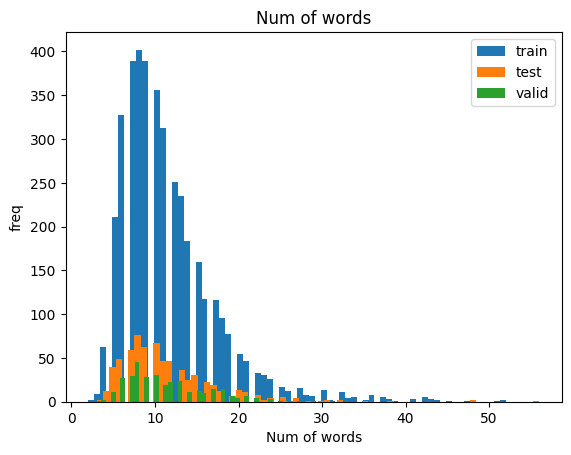

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(1,1,1)

ax.set_title('Num of words')
ax.set_xlabel('Num of words')
ax.set_ylabel('freq')
ax.hist([ len(x) for x in df_train['Sequence'] ] , bins=70, label="train")
ax.hist([ len(x) for x in df_test['Sequence'] ] , bins=70, label="test")
ax.hist([ len(x) for x in df_valid['Sequence'] ] , bins=70, label="valid")
ax.legend()
fig.show()

As a result of the processing so far, some records now have an input length of 0.

We exclude the rows whose input length is 0.

In [ ]:
df_train = df_train[df_train['Sequence'].map(lambda x: len(x) > 0)]
df_valid = df_valid[df_valid['Sequence'].map(lambda x: len(x) > 0)]
df_test = df_test[df_test['Sequence'].map(lambda x: len(x) > 0)]

print('train:{}, valid:{}, test:{}'.format(len(df_train), len(df_valid), len(df_test)))

train_sequences = df_train['Sequence']
validation_sequences = df_valid['Sequence']
test_sequences = df_test['Sequence']

train:4018, valid:335, test:670


### Padding the input data to a uniform length of MAX_LEN
Here, with padding='pre', truncating='pre', and value=0.0, we specify that when a record is too short it is zero-padded at the beginning, and when a record is too long it is truncated from the beginning.

In [ ]:
train_padded_sequences = tf.keras.preprocessing.sequence.pad_sequences(train_sequences,
                                                                       maxlen=MAX_LENGTH,
                                                                       dtype='int32',
                                                                       padding='pre',
                                                                       truncating='pre',
                                                                       value=0.0)

validation_padded_sequences = tf.keras.preprocessing.sequence.pad_sequences(validation_sequences,
                                                                       maxlen=MAX_LENGTH,
                                                                       dtype='int32',
                                                                       padding='pre',
                                                                       truncating='pre',
                                                                       value=0.0)

test_padded_sequences = tf.keras.preprocessing.sequence.pad_sequences(test_sequences,
                                                                       maxlen=MAX_LENGTH,
                                                                       dtype='int32',
                                                                       padding='pre',
                                                                       truncating='pre',
                                                                       value=0.0)

Let's look at the first 5 rows of the length-normalized test data.

In [ ]:
test_padded_sequences[:5]

array([[   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0, 

### Extracting the label data

In [ ]:
train_labels = df_train['is_counterfactual'].copy()
validation_labels = df_valid['is_counterfactual'].copy()
test_labels = df_test['is_counterfactual'].copy()

At this point, we have prepared the following.


Usage | Purpose | Count | Data | Labels (1: counterfactual, 0: factual)
--- | --- | --- | --- | ---
train | Training data | 5,600 | train_padded_sequences | train_labels
valid | Validation data | 466 | validation_padded_sequences | validation_labels
test | Test data | 934 | test_padded_sequences | test_labels

### Checking the number of records per ground-truth label

Let's check roughly how many records there are for each class (0 or 1) of the ground-truth label ("is_counterfactual").
 * If you train directly on a dataset whose ground-truth label classes are imbalanced (imbalanced data), you may end up with a classifier that simply assigns every record to the majority class.
  - Suppose you have a dataset consisting of "9,990 instances of class A," "9 instances of class B," and "1 instance of class C." A classifier that labels every record as "class A" would achieve 99.9% accuracy, yet such a classifier would be completely useless.
  

In [ ]:
display(train_labels.value_counts().to_frame().T)

is_counterfactual,0,1
count,3253,765


In [ ]:
display(validation_labels.value_counts().to_frame().T)

is_counterfactual,0,1
count,277,58


In [ ]:
display(test_labels.value_counts().to_frame().T)

is_counterfactual,0,1
count,539,131


Approaches to dealing with imbalanced data can be broadly divided into the following three:
1. Weighting
2. Sampling
3. Treating it as an anomaly-detection problem

Because it is easy to implement, here we adopt a method belonging to category 1: weighting in the loss function.<br>
This is a technique that assigns weights to the minority class during training, thereby making the model treat the minority class as more important.

In [ ]:
from sklearn.utils import class_weight
class_weights = class_weight.compute_class_weight(class_weight = 'balanced',
                                                 classes = np.unique(train_labels),
                                                 y = train_labels)
class_weights = {i : class_weights[i] for i in range(len(class_weights))}

In [ ]:
print("Weight of majority class [0]: {:.6f},  Weight of minority class [1]: {:.6f}"\
      .format(class_weights[0], class_weights[1]))

Weight of majority class [0]: 0.617584,  Weight of minority class [1]: 2.626144


### Defining the TensorFlow model

We now define the model.



In [ ]:
# Input layer: (batch_size x MAX_LENGTH channels)
inputs = tf.keras.layers.Input(shape = (MAX_LENGTH,), name = 'input')

# Embedding layer
# input_dim: number of words to analyze (size of the vocabulary)
# output_dim: dimensionality after embedding (dimension of the dense embedding)
x = tf.keras.layers.Embedding(input_dim = VOCAB_SIZE, output_dim = EMB_DIMS )(inputs)

# GlobalAveragePooling layer
x = tf.keras.layers.GlobalAveragePooling1D()(x)

# Fully connected (dense) layer
outputs = tf.keras.layers.Dense(units = NUM_LABELS, activation='softmax')(x)

# Define the model
model = tf.keras.Model( inputs = inputs, outputs = outputs, name = 'securities_model' )

# Print the model architecture as text
model.summary()

Model: "securities_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 200, 8)         │       240,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 8)              │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │            18 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 240,018 (937.57 KB)

 Trainable params: 240,018 (937.57 KB)

 Non-trainable params: 0 (0.00 B)

### Training the model

In [ ]:
# Prepare to create a log file during training
callbacks = []
callbacks.append(tf.keras.callbacks.CSVLogger('training_log.csv'))

# Compile the model
model.compile(optimizer=tf.keras.optimizers.Adam(2.0e-3), # optimization algorithm
              loss=tf.keras.losses.CategoricalCrossentropy(), # loss function
              metrics=['accuracy'] # metric for monitoring (does not affect the training of the model itself)
              )

# Train the model (about 3 minutes)
history = model.fit(x = train_padded_sequences, y = tf.one_hot(train_labels.values, depth=NUM_LABELS),
                    batch_size = 256,
                    epochs = EPOCHS,
                    validation_data = (validation_padded_sequences, tf.one_hot(validation_labels.values, depth=NUM_LABELS)),
                    callbacks = callbacks
                    )

Epoch 1/120
16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 55ms/step - accuracy: 0.8096 - loss: 0.5095 - val_accuracy: 0.8269 - val_loss: 0.4727
Epoch 2/120
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.8096 - loss: 0.4887 - val_accuracy: 0.8269 - val_loss: 0.4604
Epoch 3/120
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.8096 - loss: 0.4875 - val_accuracy: 0.8269 - val_loss: 0.4608
Epoch 4/120
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.8096 - loss: 0.4856 - val_accuracy: 0.8269 - val_loss: 0.4602
Epoch 5/120
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.8096 - loss: 0.4852 - val_accuracy: 0.8269 - val_loss: 0.4596
Epoch 6/120
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8096 - loss: 0.4847 - val_accuracy: 0.8269 - val_loss: 0.4594
Epoch 7/120
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8096 - loss: 0.4840 - val_accuracy: 0.8269 - val_loss: 0.4590
Epoch 8/120
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8096 - loss: 0.4835 - val_accuracy: 0

### Plotting the training progress

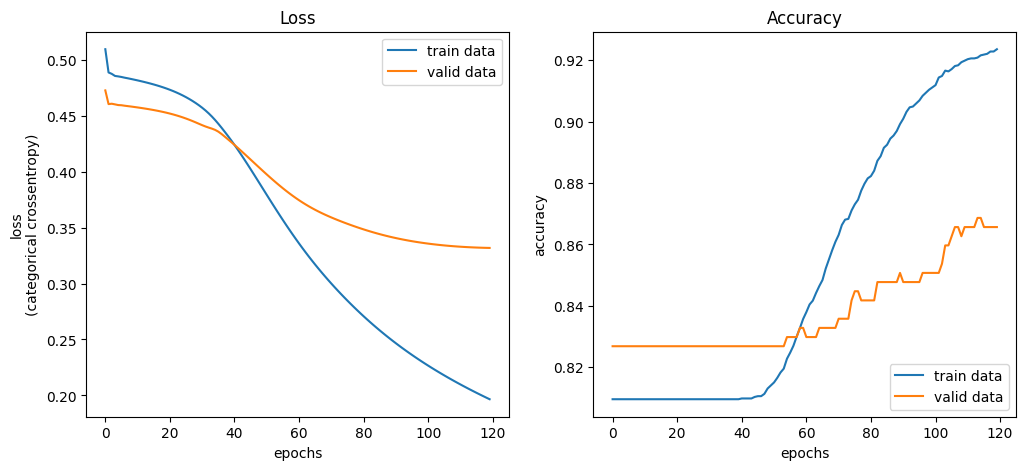

In [ ]:
# Load the log file
log_df = pd.read_csv('training_log.csv')

epochs = log_df["epoch"].values
train_acc = log_df["accuracy"].values
train_loss = log_df["loss"].values
valid_acc = log_df["val_accuracy"].values
valid_loss = log_df["val_loss"].values

fig, axes = plt.subplots(1,2, figsize=(12,5))

axes[0].plot(epochs, train_loss, label="train data")
axes[0].plot(epochs, valid_loss, label="valid data")
axes[0].set_xlabel("epochs")
axes[0].set_ylabel("loss\n(categorical crossentropy)")
axes[0].legend(loc="upper right")
axes[0].set_title("Loss")

axes[1].plot(epochs, train_acc, label="train data")
axes[1].plot(epochs, valid_acc, label="valid data")
axes[1].set_xlabel("epochs")
axes[1].set_ylabel("accuracy")
axes[1].legend(loc="lower right")
axes[1].set_title("Accuracy")

plt.show()

### Evaluating the model with the test data

In [ ]:
loss, acc = model.evaluate(test_padded_sequences, tf.one_hot(test_labels, depth=NUM_LABELS))
print("\nLoss:{}, Accuracy:{}".format(loss, acc))

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8642 - loss: 0.3010

Loss:0.3009699881076813, Accuracy:0.8641790747642517


### Checking the model's inference results

Let's look at the model's inference results on the test data.

In [ ]:
predictions = model.predict(test_padded_sequences)

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [ ]:
display(predictions[:5])

array([[0.9005682 , 0.09943179],
       [0.9480295 , 0.05197047],
       [0.9851372 , 0.01486272],
       [0.9832282 , 0.01677179],
       [0.9887761 , 0.01122399]], dtype=float32)

We use the np.argmax() function to take the class with the largest output value as the prediction.

In [ ]:
df_test['Prediction'] = np.argmax(predictions, axis=1)

# Convert the numeric labels predicted by the model into readable label names (factual/counterfactual)
df_test['Prediction_to_Label_names'] = df_test['Prediction'].map({0:'factual', 1:'counterfactual'})

# Print the first 30 rows
display(df_test.head(30))

,sentence,is_counterfactual,Sequence,Prediction,Prediction_to_Label_names
0,The one came TV lasted well 0 years crap laste...,0,"[8, 9, 28, 118, 2546, 27, 4, 158, 1702, 2546, ...",0,factual
1,Really know I would without this.,0,"[21, 46, 2, 3, 6, 16]",0,factual
2,"""This book belong \best ever\"""" category \""""cl...",0,"[16, 13, 5829, 180, 232, 1, 1, 1, 15, 2285, 22...",0,factual
3,The sweater soft washes well without pilling.,0,"[8, 984, 289, 2785, 27, 6, 2977]",0,factual
4,My 0 year old fits jumpsuit size 0t-0t except ...,0,"[76, 4, 226, 146, 121, 5391, 26, 1819, 1819, 5...",0,factual
5,Fun read Could little longer detail.,1,"[701, 14, 11, 18, 147, 660]",0,factual
6,Maybe make sense things book connect.,0,"[244, 63, 1116, 150, 13, 788]",0,factual
7,"""You able tell difference \\\\\expensive\\\\\""...",0,"[85, 73, 322, 518, 356, 330, 470]",0,factual
8,works well like intended wish cord longer flat...,1,"[79, 27, 10, 1656, 12, 263, 147, 680, 369]",0,factual
9,An earlier post said big head fit well must bi...,0,"[2076, 1120, 1416, 208, 102, 248, 29, 27, 17, ...",0,factual


We check this model's performance with a confusion matrix.

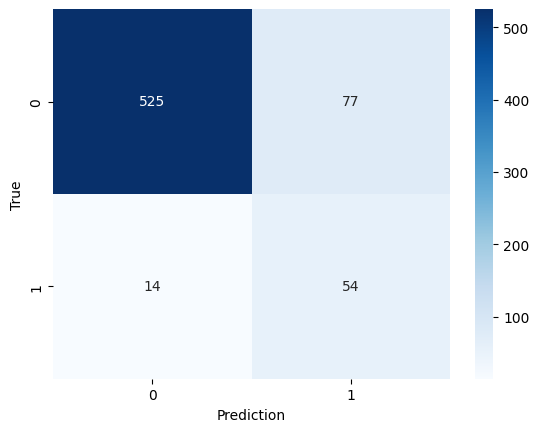

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(df_test['Prediction'], test_labels)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Prediction')
plt.ylabel("True")
plt.savefig('klearn_confusion_matrix.png')

Let's print only the review records whose ground-truth label "is_counterfactual" is 1 (counterfactual).

In [ ]:
display(df_test.loc[df_test.loc[:,"is_counterfactual"]==1])

,sentence,is_counterfactual,Sequence,Prediction,Prediction_to_Label_names
5,Fun read Could little longer detail.,1,"[701, 14, 11, 18, 147, 660]",0,factual
8,works well like intended wish cord longer flat...,1,"[79, 27, 10, 1656, 12, 263, 147, 680, 369]",0,factual
14,I wear extra large seems like I ordered one si...,1,"[2, 52, 262, 123, 202, 10, 2, 61, 9, 26, 233]",0,factual
24,"Still cute top, I probably gone 0X, 0 sizes la...",1,"[45, 274, 115, 2, 141, 618, 1061, 4, 505, 233,...",0,factual
31,"It work well hoping would, waste money.",1,"[5, 38, 27, 510, 3, 722, 157]",0,factual
...,...,...,...,...,...
617,I like Purple NWZ S0 wish I could gotten anoth...,1,"[2, 10, 2300, 1, 4208, 12, 2, 11, 362, 70, 97,...",1,counterfactual
621,I could used recap remember I wait get back ch...,1,"[2, 11, 55, 3730, 1049, 2, 275, 20, 57, 188, 2...",0,factual
624,I wish I I teaching.,1,"[2, 12, 2, 2, 1]",1,counterfactual
634,It felt like band-aid try bond two characters ...,1,"[5, 206, 10, 494, 5786, 287, 1, 96, 188, 1]",0,factual


## Analysis with the model we built

Try changing the free_test string in the program below and let the model judge whether the sentence is counterfactual.

In [ ]:
free_test = ["It would be perfect if it were more durable."]

# ------------------------------------

class_c =['factual','counterfactual']
df_free_test = pd.DataFrame({ 'sentence' : free_test})
df_free_test['sentence'] = df_free_test['sentence']#.str.split(' ', expand=True)#.map(wakati)
df_free_test['Sequence'] = tokenizer.texts_to_sequences(df_free_test['sentence'])

print(df_free_test)
free_test_sequences = df_free_test['Sequence']
free_test_padded_sequences = tf.keras.preprocessing.sequence.pad_sequences(free_test_sequences,
                                                                       maxlen=MAX_LENGTH,
                                                                       dtype='int32',
                                                                       padding='pre',
                                                                       truncating='pre',
                                                                       value=0.0)
predictions = model.predict(free_test_padded_sequences)

print('\nAnalysis result: {}'.format(class_c[np.argmax(predictions, axis=1)[0]]))



                                       sentence  \
0  It would be perfect if it were more durable.   

                                  Sequence  
0  [5, 3, 136, 82, 34, 5, 1400, 237, 1691]  
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step

Analysis result: counterfactual


## Let's look at the intermediate outputs of the model we built

To inspect the output of the embedding layer, we create activation_model1.

To inspect the output of the global_average_pooling1d layer, we create activation_model2.



In [ ]:
display( model.summary() )

Model: "securities_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 200, 8)         │       240,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 8)              │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │            18 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 720,056 (2.75 MB)

 Trainable params: 240,018 (937.57 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 480,038 (1.83 MB)

None

In [ ]:
# Since the input layer is index 0, index 1 is the embedding layer and index 2 is the global_average_pooling1d layer.
print('Layer 0')
print(model.layers[0])
print('Layer 1')
print(model.layers[1])
print('Layer 2')
print(model.layers[2])

Layer 0
<InputLayer name=input, built=True>
Layer 1
<Embedding name=embedding, built=True>
Layer 2
<GlobalAveragePooling1D name=global_average_pooling1d, built=True>


In [ ]:
# Input layer: (batch_size x MAX_LENGTH channels)
inputs_act1 = tf.keras.layers.Input(shape = (MAX_LENGTH,), name = 'input_act1')
# Inspect the output of the embedding layer
outputs_act1 = (model.layers[1])(inputs_act1)

# Define the activation_model1 model
activation_model1 = tf.keras.Model( inputs = inputs_act1, outputs = outputs_act1, name = 'act1_model' )


# Input layer: (batch_size x MAX_LENGTH channels)
inputs_act2 = tf.keras.layers.Input(shape = (MAX_LENGTH,), name = 'input_act2')
x_act2 = (model.layers[1])(inputs_act2)
# Inspect the output of the global_average_pooling1d layer
outputs_act2 = (model.layers[2])(x_act2)

# Define the activation_model2 model
activation_model2 = tf.keras.Model( inputs = inputs_act2, outputs = outputs_act2, name = 'act2_model' )



We feed the test data into activation_model1 and activation_model2.

In [ ]:
activations1 = activation_model1.predict(test_padded_sequences)
activations2 = activation_model2.predict(test_padded_sequences)

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


Let's check the very first record of the test data fed into activation_model1.
This is the output of the embedding layer.

In [ ]:
print(activations1[0])

[[ 0.21809252 -0.24940883  0.18693022 ... -0.14134404 -0.2795709
   0.14945255]
 [ 0.21809252 -0.24940883  0.18693022 ... -0.14134404 -0.2795709
   0.14945255]
 [ 0.21809252 -0.24940883  0.18693022 ... -0.14134404 -0.2795709
   0.14945255]
 ...
 [-0.8766351  -1.1396171  -0.928442   ...  1.037869   -1.0649145
  -0.9202699 ]
 [-1.0266867  -1.7225466  -0.9969078  ...  1.0461341  -1.3386415
  -0.9986923 ]
 [ 0.46772185  0.61989534  0.53215754 ... -0.57795936  0.5552387
   0.51636606]]


Let's check the very first record of the test data fed into activation_model2.
This is the output of the global_average_pooling1d layer.

In [ ]:
print(activations2[0])

[ 0.21342266 -0.22709091  0.18381189  0.14909081 -0.17331626 -0.14236389
 -0.25330484  0.14921026]
